In [19]:
import numpy as np
import matplotlib.pyplot as plt

from simulation.scene_generator   import PointsGenerator
from simulation.camera_model      import get_K, get_camera_pose
from simulation.projection        import project_points, filter_visible
from simulation.homography        import homography, decompose_H
from eight_points.eight_point_agl import eight_point
from eight_points.Retrieve_P      import get_R_t_from_epipolar, P_estimation, parallax, find_scaling_factor
from eight_points.RANSAC          import RANSAC, score_H_RANSAC, score_F_RANSAC
from pipeline.score               import score_H, score_F
from eight_points.triangulation   import triangulate

In [2]:
def residual_F(px1, px2, F):
    N = px1.shape[1]
    h1 = np.vstack([px1, np.ones((1, N))])
    h2 = np.vstack([px2, np.ones((1, N))])
    # Epipolar lines
    Fx1  = F @ h1                                             # (3, N)
    Ftx2 = F.T @ h2                                           # (3, N)
    num = np.sum(h2 * Fx1, axis=0) ** 2
    denom1 = Fx1[0]**2 + Fx1[1]**2                            # (N,)
    denom2 = Ftx2[0]**2 + Ftx2[1]**2                          # (N,)
    d2_sym = num * (1.0 / (denom1 + 1e-12) + 1.0 / (denom2 + 1e-12))
    total_error = 1/N * np.sum(d2_sym)
    return total_error


def make_scene(
    n_points=1000, 
    scene_type='3d', 
    x_range=2.0, 
    y_range=1.5, 
    z_min=5.0, 
    z_max=15.0,
    fx=1000.0, fy=1000.0, cx=960.0, cy=540.0, 
    img_w=1920, img_h=1080,
    cam1_rx=0.0, cam1_ry=0.0, cam1_rz=0.0, cam1_tx=0.0, cam1_ty=0.0, cam1_tz=0.0,
    cam2_rx=0.0, cam2_ry=8.0, cam2_rz=0.0, cam2_tx=0.4, cam2_ty=0.0, cam2_tz=0.0,
    noise_sigma=1.0, 
    outlier_ratio=0.1,
    seed=42
):
    """
    Generates a synthetic scene seen by two cameras.
    Returns a dict: pts3d, px1, px2, K, R_rel, t_rel, R1, t1.
    """
    rng = np.random.default_rng(seed)

    # 1. Generate 3D Points
    xs = rng.uniform(-x_range, x_range, n_points)
    ys = rng.uniform(-y_range, y_range, n_points)

    if scene_type == 'planar':
        zs = np.full(n_points, z_min)
    else:
        lo, hi = min(z_min, z_max), max(z_min, z_max)
        zs = rng.uniform(lo, hi, n_points)

    pts3d = np.vstack([xs, ys, zs])
    
    # 2. Camera Intrinsics
    K = np.array([[fx,  0, cx],
                  [ 0, fy, cy],
                  [ 0,  0,  1]], dtype=np.float64)

    # 3. Camera Poses (Extrinsics)
    R1, t1 = get_camera_pose(cam1_rx, cam1_ry, cam1_rz,
                             cam1_tx, cam1_ty, cam1_tz)
    R2, t2 = get_camera_pose(cam2_rx, cam2_ry, cam2_rz,
                             cam2_tx, cam2_ty, cam2_tz)

    R_rel = R2 @ R1.T
    t_rel = t2 - R_rel @ t1

    # 4. Project and Filter Visible Points
    px1_c, d1 = project_points(pts3d, K, R1, t1)
    px2_c, d2 = project_points(pts3d, K, R2, t2)
    
    vis = (filter_visible(px1_c, d1, img_w, img_h) &
           filter_visible(px2_c, d2, img_w, img_h))

    px1 = px1_c[:, vis].copy()
    px2 = px2_c[:, vis].copy()
    M   = px1.shape[1]

    # 5. Inject Gaussian Noise
    if noise_sigma > 0 and M > 0:
        nrng = np.random.default_rng(seed + 1000)
        px1 += nrng.normal(0, noise_sigma, px1.shape)
        px2 += nrng.normal(0, noise_sigma, px2.shape)

    # 6. Inject Outliers (False Matches)
    if outlier_ratio > 0 and M > 0:
        orng  = np.random.default_rng(seed + 2000)
        n_out = min(max(1, int(round(M * outlier_ratio))), M)
        idx   = orng.choice(M, n_out, replace=False)
        px2[0, idx] = orng.uniform(0, img_w, n_out)
        px2[1, idx] = orng.uniform(0, img_h, n_out)

    return {
        'pts3d': pts3d[:, vis], 
        'px1': px1, 
        'px2': px2,
        'K': K, 
        'R_rel': R_rel, 
        't_rel': t_rel,
        'R1': R1, 
        't1': t1,
    }

# Generate scene

In [3]:
# 1 Génération de la scène 
Nb_pts = 100
res_F = np.full((1, Nb_pts + 1), np.nan)
bounds = np.array([-2.0, 2.0, -1.5, 1.5, 10, 20])
pts3d  = PointsGenerator(nbPoints=200, seed=41, bounds=bounds)

    # 2 Définition des caméras 
K = get_K()
R1, t1 = np.eye(3), np.zeros(3)
R2, t2 = get_camera_pose(rz=10, tx=4, ty = 2)

# 3 Projection 
px1, d1 = project_points(pts3d, K, R1, t1)
px2, d2 = project_points(pts3d, K, R2, t2)

# 4 Filtrage 
vis = filter_visible(px1, d1) & filter_visible(px2, d2)
pts3d_vis = pts3d[:, vis]
#print(f"Points visibles dans les deux caméras : {vis.sum()} / {pts3d.shape[1]}")
px1_vis = px1[:, vis]
px2_vis = px2[:, vis]
rng_noise = np.random.default_rng(1)
#px1_vis = px1_vis + rng_noise.normal(0, 1, px1_vis.shape)
px1_vis_main = px1_vis
px2_vis = px2_vis + rng_noise.normal(0, 1, px2_vis.shape)
px2_vis_main = px2_vis
for i in range(8, Nb_pts + 1):
    
    px1_vis = px1_vis_main[:, :i]
    px2_vis = px2_vis_main[:, :i]
    
    ransac_solver_F = RANSAC(
    s=8, 
    score_fct=score_F_RANSAC,
    model_fct=eight_point, 
    px1=px1_vis, 
    px2=px2_vis,
    epsilon=None
    )
    F_Ransac, mask = ransac_solver_F.execute_RANSAC()
    clean_px1 = px1_vis[:, mask]
    clean_px2 = px2_vis[:, mask]
    res_F[0, i] = residual_F(px1_vis_main, px2_vis_main, F_Ransac)

# Plot Residual error vs number of points

<>:11: SyntaxWarning: invalid escape sequence '\s'
<>:11: SyntaxWarning: invalid escape sequence '\s'
C:\Users\thien\AppData\Local\Temp\ipykernel_23944\609944529.py:11: SyntaxWarning: invalid escape sequence '\s'
  plt.axhline(y=1.75, color='red', linestyle='--', linewidth=2, label='Noise Floor ($\sigma=1$)')


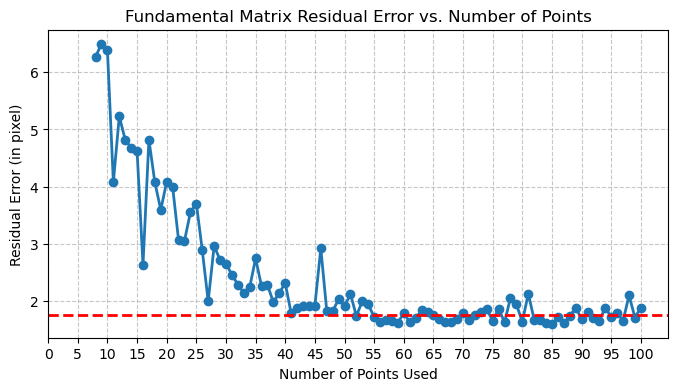

In [4]:
residuals = res_F[0] 

# 2. Create an X-axis array representing the number of points (0 to 50)
n_points = np.arange(len(residuals))

# 3. Set up the plot
plt.figure(figsize=(8, 4))

# Plot the data. Matplotlib ignores the NaNs at indices 0-7!
plt.plot(n_points, residuals, marker='o', linestyle='-', linewidth=2)
plt.axhline(y=1.75, color='red', linestyle='--', linewidth=2, label='Noise Floor ($\sigma=1$)')
# 4. Add labels and styling to make it look professional for analysis
plt.title("Fundamental Matrix Residual Error vs. Number of Points")
plt.xlabel("Number of Points Used")
plt.ylabel("Residual Error (in pixel)")
plt.grid(True, linestyle='--', alpha=0.7)

# Ensure the X-axis shows integer ticks (since you can't have a fraction of a point)
plt.xticks(np.arange(0, Nb_pts + 5, 5))

# 5. Display the plot
plt.show()

# Thresholding when it changes from H to F

In [5]:
noise_sigmas = np.linspace(0, 4, 21)
nb_px = np.arange(50, 251, 50)

# 1. Initialize a 2D array filled with NaNs to store the results
# Rows will represent the noise level (index 'r')
# Columns will represent the point count (index 'c')
ratio_matrix = np.full((len(noise_sigmas), len(nb_px)), np.nan)

# 2. Use enumerate() to easily grab the row and column indices for saving
for r, i in enumerate(noise_sigmas):
    for c, j in enumerate(nb_px):
        
        # FIX: Pass 'j' (the scalar) instead of 'nb_px' (the full array)
        scene_data = make_scene(n_points=j, scene_type="planar", outlier_ratio=0, noise_sigma=i)
        
        pts3d = scene_data['pts3d']
        px1 = scene_data['px1']
        px2 = scene_data['px2']
        
        # --- Evaluate Fundamental Matrix ---
        ransac_F = RANSAC(
            s=8,
            score_fct=score_F_RANSAC,
            model_fct=eight_point,
            px1=px1,
            px2=px2,
            epsilon=0, 
        )
        F, mask_F = ransac_F.execute_RANSAC()
        
        # Safe check: if RANSAC fails, leave the NaN in the matrix and skip to the next loop
        if F is None or mask_F is None or np.sum(mask_F) < 8:
            continue
            
        clean_px1_F   = px1[:, mask_F]
        clean_px2_F   = px2[:, mask_F]
        S_F = score_F(F, clean_px1_F, clean_px2_F)
        
        # --- Evaluate Homography ---
        ransac_H = RANSAC(
            s=4,
            score_fct=score_H_RANSAC,
            model_fct=homography,
            px1=px1,
            px2=px2,
            epsilon=0, 
        )
        H, mask_H = ransac_H.execute_RANSAC()
        
        if H is None or mask_H is None or np.sum(mask_H) < 4:
            continue
            
        clean_px1_H   = px1[:, mask_H]
        clean_px2_H   = px2[:, mask_H]
        S_H      = score_H(H, clean_px1_H, clean_px2_H)
        
        # 3. Calculate the ratio and save it to the matrix
        # Epsilon (1e-12) added to the denominator to prevent division by zero errors
        ratio = S_H / (S_H + S_F)
        ratio_matrix[r, c] = ratio

<>:11: SyntaxWarning: invalid escape sequence '\s'
<>:11: SyntaxWarning: invalid escape sequence '\s'
C:\Users\thien\AppData\Local\Temp\ipykernel_23944\2170172924.py:11: SyntaxWarning: invalid escape sequence '\s'
  plt.xlabel("Gaussian Noise Level ($\sigma$)", fontsize=12)


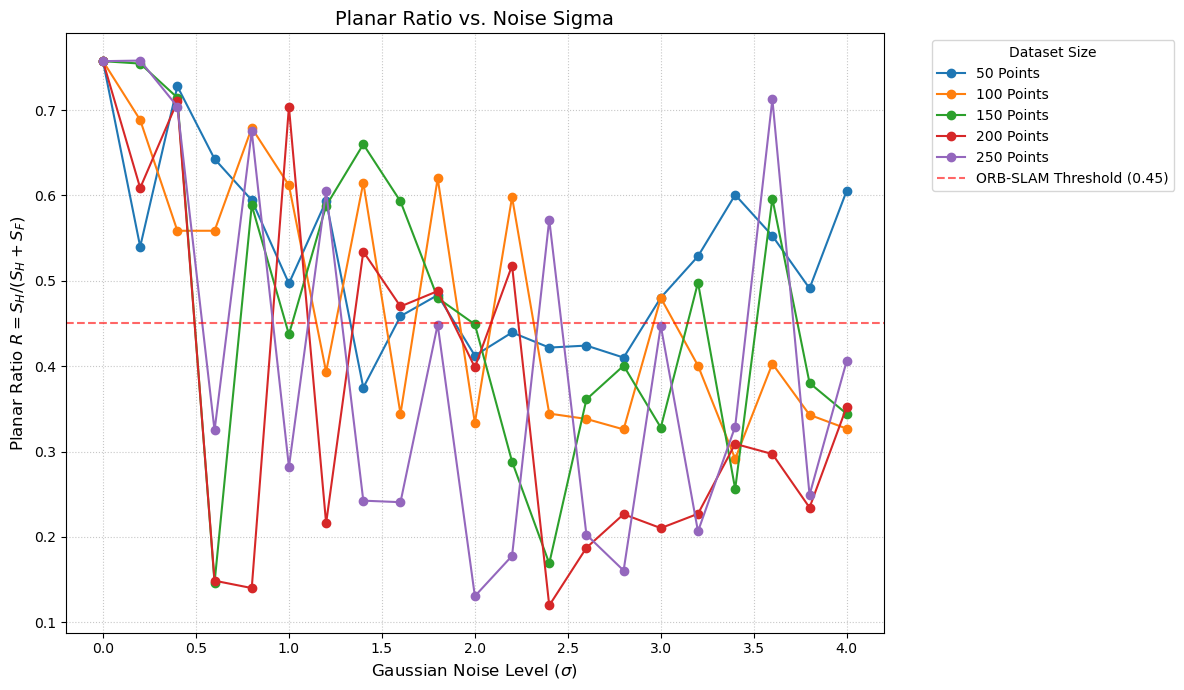

In [6]:
plt.figure(figsize=(12, 7))

# We iterate through the columns (point counts)
# Slicing [:, 1:] to get 9 curves (skipping the first column of 50 points)
for c in range(0, ratio_matrix.shape[1]):
    label_pts = nb_px[c]
    plt.plot(noise_sigmas, ratio_matrix[:, c], marker='o', label=f'{label_pts} Points')

# Formatting the plot
plt.title("Planar Ratio vs. Noise Sigma", fontsize=14)
plt.xlabel("Gaussian Noise Level ($\sigma$)", fontsize=12)
plt.ylabel("Planar Ratio $R = S_H / (S_H + S_F)$", fontsize=12)

# Adding a horizontal line for the ORB-SLAM decision threshold
plt.axhline(y=0.45, color='r', linestyle='--', alpha=0.6, label='ORB-SLAM Threshold (0.45)')

plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(title="Dataset Size", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.show()

In [7]:
noise_sigmas = np.linspace(0, 4, 21)
nb_px = np.arange(50, 251, 50)

# 1. Initialize a 2D array filled with NaNs to store the results
# Rows will represent the noise level (index 'r')
# Columns will represent the point count (index 'c')
ratio_matrix = np.full((len(noise_sigmas), len(nb_px)), np.nan)

# 2. Use enumerate() to easily grab the row and column indices for saving
for r, i in enumerate(noise_sigmas):
    for c, j in enumerate(nb_px):
        
        # FIX: Pass 'j' (the scalar) instead of 'nb_px' (the full array)
        scene_data = make_scene(n_points=j, scene_type="planar", outlier_ratio=0, noise_sigma=i)
        
        pts3d = scene_data['pts3d']
        px1 = scene_data['px1']
        px2 = scene_data['px2']
        
        # --- Evaluate Fundamental Matrix ---
        ransac_F = RANSAC(
            s=8,
            score_fct=score_F_RANSAC,
            model_fct=eight_point,
            px1=px1,
            px2=px2,
            epsilon=None, 
        )
        F, mask_F = ransac_F.execute_RANSAC()
        
        # Safe check: if RANSAC fails, leave the NaN in the matrix and skip to the next loop
        if F is None or mask_F is None or np.sum(mask_F) < 8:
            continue
            
        clean_px1_F   = px1[:, mask_F]
        clean_px2_F   = px2[:, mask_F]
        S_F = score_F(F, clean_px1_F, clean_px2_F)
        
        # --- Evaluate Homography ---
        ransac_H = RANSAC(
            s=4,
            score_fct=score_H_RANSAC,
            model_fct=homography,
            px1=px1,
            px2=px2,
            epsilon=None, 
        )
        H, mask_H = ransac_H.execute_RANSAC()
        
        if H is None or mask_H is None or np.sum(mask_H) < 4:
            continue
            
        clean_px1_H   = px1[:, mask_H]
        clean_px2_H   = px2[:, mask_H]
        S_H      = score_H(H, clean_px1_H, clean_px2_H)
        
        # 3. Calculate the ratio and save it to the matrix
        # Epsilon (1e-12) added to the denominator to prevent division by zero errors
        ratio = S_H / (S_H + S_F)
        ratio_matrix[r, c] = ratio

<>:11: SyntaxWarning: invalid escape sequence '\s'
<>:11: SyntaxWarning: invalid escape sequence '\s'
C:\Users\thien\AppData\Local\Temp\ipykernel_23944\2170172924.py:11: SyntaxWarning: invalid escape sequence '\s'
  plt.xlabel("Gaussian Noise Level ($\sigma$)", fontsize=12)


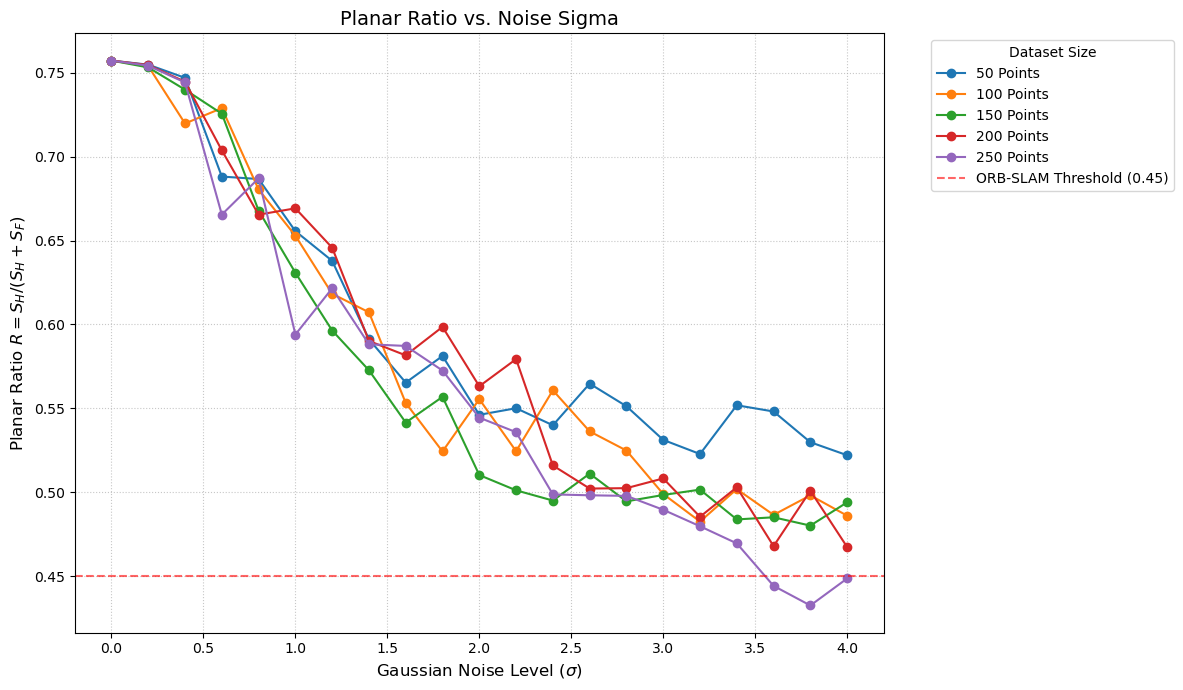

In [8]:
plt.figure(figsize=(12, 7))

# We iterate through the columns (point counts)
# Slicing [:, 1:] to get 9 curves (skipping the first column of 50 points)
for c in range(0, ratio_matrix.shape[1]):
    label_pts = nb_px[c]
    plt.plot(noise_sigmas, ratio_matrix[:, c], marker='o', label=f'{label_pts} Points')

# Formatting the plot
plt.title("Planar Ratio vs. Noise Sigma", fontsize=14)
plt.xlabel("Gaussian Noise Level ($\sigma$)", fontsize=12)
plt.ylabel("Planar Ratio $R = S_H / (S_H + S_F)$", fontsize=12)

# Adding a horizontal line for the ORB-SLAM decision threshold
plt.axhline(y=0.45, color='r', linestyle='--', alpha=0.6, label='ORB-SLAM Threshold (0.45)')

plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(title="Dataset Size", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.show()

# Histogram of reprojection error (Sampson distance)

184


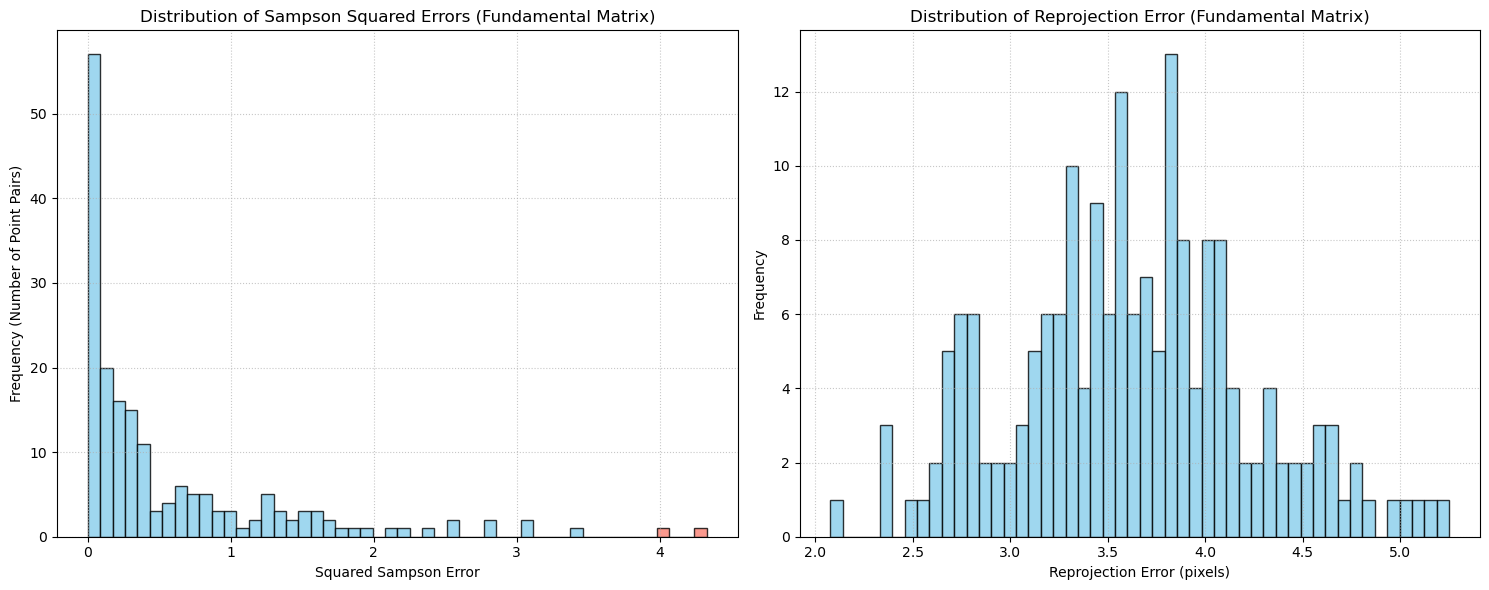

In [31]:
def get_dsamp_F(F, px1, px2, threshold=3.84):
    """
    Symmetric Sampson distance score for fundamental matrix F (ORB-SLAM style).

    Sampson distance is the first-order approximation of the reprojection error
    under the epipolar constraint x2ᵀFx1 = 0 :

      d²_sampson = (x2ᵀFx1)² / (‖Fx1‖²_top2 + ‖Fᵀx2‖²_top2)

      S_F = Σ max(0, T - d²_sampson)

    threshold : chi² at 95% for 1 DOF = 3.84  (epipolar constraint is 1D)

    Returns: float  (higher = better fit)
    """
    N = px1.shape[1]
    h1 = np.vstack([px1, np.ones((1, N))])
    h2 = np.vstack([px2, np.ones((1, N))])

    Fx1  = F @ h1                                              # (3, N)
    Ftx2 = F.T @ h2                                           # (3, N)

    num      = np.sum(h2 * Fx1, axis=0) ** 2                  # (x2ᵀFx1)²
    denom    = Fx1[0]**2 + Fx1[1]**2 + Ftx2[0]**2 + Ftx2[1]**2
    d_samp   = num / (denom + 1e-12)
    return d_samp

Nb_pts = 100
res_F = np.full((1, Nb_pts + 1), np.nan)
bounds = np.array([-2.0, 2.0, -1.5, 1.5, 10, 20])
pts3d  = PointsGenerator(nbPoints=200, seed=41, bounds=bounds)

    # 2 Définition des caméras 
K = get_K()
R1, t1 = np.eye(3), np.zeros(3)
R2, t2 = get_camera_pose(rz=10, tx=4, ty = 2)

# 3 Projection 
px1, d1 = project_points(pts3d, K, R1, t1)
px2, d2 = project_points(pts3d, K, R2, t2)

# 4 Filtrage 
vis = filter_visible(px1, d1) & filter_visible(px2, d2)
pts3d_vis = pts3d[:, vis]
#print(f"Points visibles dans les deux caméras : {vis.sum()} / {pts3d.shape[1]}")
px1_vis = px1[:, vis]
px2_vis = px2[:, vis]
rng_noise = np.random.default_rng(1)
px1_vis = px1_vis + rng_noise.normal(0, 1, px1_vis.shape)
px1_vis_main = px1_vis
px2_vis = px2_vis + rng_noise.normal(0, 1, px2_vis.shape)
px2_vis_main = px2_vis

ransac_solver_F = RANSAC(
    s=8, 
    score_fct=score_F_RANSAC,
    model_fct=eight_point, 
    px1=px1_vis, 
    px2=px2_vis,
    epsilon=None
    )
F_Ransac, mask = ransac_solver_F.execute_RANSAC()
clean_px1 = px1_vis[:, mask]
clean_px2 = px2_vis[:, mask]
clean_p3d = pts3d_vis[:, mask]
d_samp = get_dsamp_F(F_Ransac, clean_px1, clean_px2)
tf, R_1f, R_2f = get_R_t_from_epipolar(F_Ransac, K = K) 

#7 Estrimate the projection matrix
P_estf = P_estimation(tf, R_1f, R_2f, K) # First method
R2_hat, t2_norm, P2_norm = parallax(P_estf, K, clean_px1, clean_px2)
s = find_scaling_factor(P2_norm, K, clean_px1, clean_px2, clean_p3d)
t2_hat = s*t2_norm
P2 = K @ np.hstack((R2_hat, t2_hat))
P1 = K@np.hstack((np.eye(3), np.zeros((3, 1))))
pts3D_triag = triangulate(P1, P2, clean_px1, clean_px2)
px1_hat, d1 = project_points(pts3D_triag, K, R1, t1)
px2_hat, d2 = project_points(pts3D_triag, K, R2_hat, t2_hat)
err1 = np.linalg.norm((clean_px1 - px1_hat))
err2 = np.linalg.norm((clean_px2 - px2_hat), axis=0)
    
# Total symmetric reprojection error
total_squared_errors = err1 + err2

threshold = 3.84
max_plot_val = threshold * 3

# Create a figure with 1 row and 2 columns, adjusting the width (15) and height (6)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# --- Plot 1: Sampson Squared Errors (Left) ---
counts1, bins1, patches1 = ax1.hist(
    np.clip(d_samp, 0, max_plot_val), 
    bins=50, 
    color='skyblue', 
    edgecolor='black', 
    alpha=0.8
)

# Color the bars that fall past the threshold red
for count, bin_edge, patch in zip(counts1, bins1, patches1):
    if bin_edge > threshold:
         patch.set_facecolor('salmon')
            
# Optional: Draw the decision boundary
# ax1.axvline(x=threshold, color='red', linestyle='--', linewidth=2, label=f'Threshold ({threshold})')

ax1.set_title("Distribution of Sampson Squared Errors (Fundamental Matrix)")
ax1.set_xlabel("Squared Sampson Error")
ax1.set_ylabel("Frequency (Number of Point Pairs)")
# ax1.legend() # Uncomment if using the axvline above
ax1.grid(True, linestyle=':', alpha=0.7)

# --- Plot 2: Reprojection Error (Right) ---
counts2, bins2, patches2 = ax2.hist(
    np.clip(err2, 0, max_plot_val), 
    bins=50, 
    color='skyblue', 
    edgecolor='black', 
    alpha=0.8
)

ax2.set_title("Distribution of Reprojection Error (Fundamental Matrix)")
ax2.set_xlabel("Reprojection Error (pixels)")
ax2.set_ylabel("Frequency")
# ax2.legend() 
ax2.grid(True, linestyle=':', alpha=0.7)

# tight_layout prevents the titles and labels from overlapping
plt.tight_layout()
plt.show()

# Special Movement

175


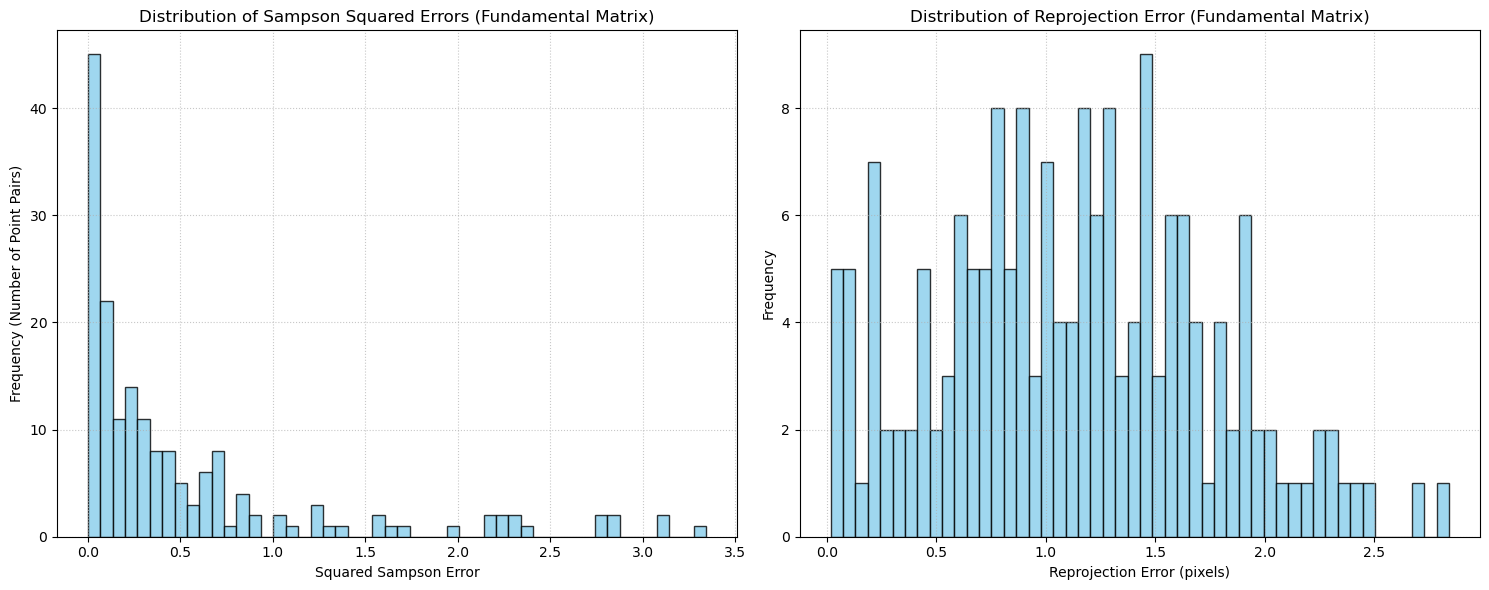

In [ ]:
def get_dsamp_F(F, px1, px2, threshold=3.84):
    """
    Symmetric Sampson distance score for fundamental matrix F (ORB-SLAM style).

    Sampson distance is the first-order approximation of the reprojection error
    under the epipolar constraint x2ᵀFx1 = 0 :

      d²_sampson = (x2ᵀFx1)² / (‖Fx1‖²_top2 + ‖Fᵀx2‖²_top2)

      S_F = Σ max(0, T - d²_sampson)

    threshold : chi² at 95% for 1 DOF = 3.84  (epipolar constraint is 1D)

    Returns: float  (higher = better fit)
    """
    N = px1.shape[1]
    h1 = np.vstack([px1, np.ones((1, N))])
    h2 = np.vstack([px2, np.ones((1, N))])

    Fx1  = F @ h1                                              # (3, N)
    Ftx2 = F.T @ h2                                           # (3, N)

    num      = np.sum(h2 * Fx1, axis=0) ** 2                  # (x2ᵀFx1)²
    denom    = Fx1[0]**2 + Fx1[1]**2 + Ftx2[0]**2 + Ftx2[1]**2
    d_samp   = num / (denom + 1e-12)
    return d_samp

Nb_pts = 100
res_F = np.full((1, Nb_pts + 1), np.nan)
bounds = np.array([-2.0, 2.0, -1.5, 1.5, 10, 20])
pts3d  = PointsGenerator(nbPoints=200, seed=41, bounds=bounds)

    # 2 Définition des caméras 
K = get_K()
R1, t1 = np.eye(3), np.zeros(3)
R2, t2 = get_camera_pose(rz=10)

# 3 Projection 
px1, d1 = project_points(pts3d, K, R1, t1)
px2, d2 = project_points(pts3d, K, R2, t2)

# 4 Filtrage 
vis = filter_visible(px1, d1) & filter_visible(px2, d2)
pts3d_vis = pts3d[:, vis]
#print(f"Points visibles dans les deux caméras : {vis.sum()} / {pts3d.shape[1]}")
px1_vis = px1[:, vis]
px2_vis = px2[:, vis]
rng_noise = np.random.default_rng(1)
px1_vis = px1_vis + rng_noise.normal(0, 1, px1_vis.shape)
px1_vis_main = px1_vis
px2_vis = px2_vis + rng_noise.normal(0, 1, px2_vis.shape)
px2_vis_main = px2_vis

ransac_solver_F = RANSAC(
    s=8, 
    score_fct=score_F_RANSAC,
    model_fct=eight_point, 
    px1=px1_vis, 
    px2=px2_vis,
    epsilon=None
    )
F_Ransac, mask = ransac_solver_F.execute_RANSAC()
clean_px1 = px1_vis[:, mask]
clean_px2 = px2_vis[:, mask]
clean_p3d = pts3d_vis[:, mask]
d_samp = get_dsamp_F(F_Ransac, clean_px1, clean_px2)
tf, R_1f, R_2f = get_R_t_from_epipolar(F_Ransac, K = K) 

#7 Estrimate the projection matrix
P_estf = P_estimation(tf, R_1f, R_2f, K) # First method
R2_hat, t2_norm, P2_norm = parallax(P_estf, K, clean_px1, clean_px2)
s = find_scaling_factor(P2_norm, K, clean_px1, clean_px2, clean_p3d)
t2_hat = s*t2_norm
P2 = K @ np.hstack((R2_hat, t2_hat))
P1 = K@np.hstack((np.eye(3), np.zeros((3, 1))))
pts3D_triag = triangulate(P1, P2, clean_px1, clean_px2)
px1_hat, d1 = project_points(pts3D_triag, K, R1, t1)
px2_hat, d2 = project_points(pts3D_triag, K, R2_hat, t2_hat)
err1 = np.linalg.norm((clean_px1 - px1_hat))
err2 = np.linalg.norm((clean_px2 - px2_hat), axis=0)

threshold = 3.84
max_plot_val = threshold * 3

# Create a figure with 1 row and 2 columns, adjusting the width (15) and height (6)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# --- Plot 1: Sampson Squared Errors (Left) ---
counts1, bins1, patches1 = ax1.hist(
    np.clip(d_samp, 0, max_plot_val), 
    bins=50, 
    color='skyblue', 
    edgecolor='black', 
    alpha=0.8
)

# Color the bars that fall past the threshold red
for count, bin_edge, patch in zip(counts1, bins1, patches1):
    if bin_edge > threshold:
         patch.set_facecolor('salmon')
            
# Optional: Draw the decision boundary
# ax1.axvline(x=threshold, color='red', linestyle='--', linewidth=2, label=f'Threshold ({threshold})')

ax1.set_title("Distribution of Sampson Squared Errors (Fundamental Matrix)")
ax1.set_xlabel("Squared Sampson Error")
ax1.set_ylabel("Frequency (Number of Point Pairs)")
# ax1.legend() # Uncomment if using the axvline above
ax1.grid(True, linestyle=':', alpha=0.7)

# --- Plot 2: Reprojection Error (Right) ---
counts2, bins2, patches2 = ax2.hist(
    np.clip(err2, 0, max_plot_val), 
    bins=50, 
    color='skyblue', 
    edgecolor='black', 
    alpha=0.8
)

ax2.set_title("Distribution of Reprojection Error (Fundamental Matrix)")
ax2.set_xlabel("Reprojection Error (pixels)")
ax2.set_ylabel("Frequency")
# ax2.legend() 
ax2.grid(True, linestyle=':', alpha=0.7)

# tight_layout prevents the titles and labels from overlapping
plt.tight_layout()
plt.show()